Imports

In [1]:
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

June 25th meeting

TODO
- Change to $\sqrt{\gamma_1}$ estimation
- Change to binary measurement of $\geq n+1$ instead of just $=n+1$
- Check photodetection CFI
- Check smaller time steps to check linear growth of CFI (no jumping)
- Debug short time CFI should go like $(\bar n + 1) \delta t$ (too large right now)
- Put units on x-axis etc
- Add linear plot for $(\bar n+1)\delta t$ to the CFI vs interrogation time plot
- Study dead time behaviour in short and long limits
- Compare dead time results (CFI and optimal time versus dead time) to the continuous limit where the total CFI is $I = \frac{T}{t+\tau}I_c(t)$ where $M\approx \frac{T}{t+\tau}$
    - Does the approximation to $M$ explain all of the non-smooth behaviour?
- Use concrete numbers from Matteo for this scenario
- Change the signal from $a^\dagger$ to $x$ or isotropic $x$ and $p$ (random force model)

CFI

In [2]:
# Adjustable parameters
n = 3                # Fock state index (dimensionless)
dim = 20             # Hilbert space dimension (dimensionless) - increased for stability
gamma_loss = 1.0     # decay rate (loss) [1/s]
gamma_gain = 0.1     # gain rate [1/s]
dt = 0.001           # time step [s] - reduced for stability
steps = 500          # number of time steps (dimensionless) - reduced for stability
delta = 1e-5         # finite difference step for Fisher information [1/s]

# Create time array in seconds
times = np.arange(steps + 1) * dt  # in seconds

# Fock state |n>
psi = np.zeros(dim, dtype=complex)
psi[n] = 1.0

# Annihilation operator
a = np.zeros((dim, dim), dtype=complex)
for i in range(1, dim):
    a[i-1, i] = np.sqrt(i)

# Creation operator (a†)
adag = a.conj().T

# Initial density matrix
rho = np.outer(psi, psi.conj())

photon_numbers = np.arange(dim)

# Updated Lindblad master equation with both loss (a) and gain (a†)
def lindblad_dissipator(rho, c):
    """Lindblad dissipator with overflow protection"""
    # Compute each term separately to avoid overflow
    term1 = c @ rho @ c.conj().T
    term2 = 0.5 * c.conj().T @ c @ rho
    term3 = 0.5 * rho @ c.conj().T @ c
    
    # Check for overflow before final computation
    if np.any(np.isinf(term1)) or np.any(np.isinf(term2)) or np.any(np.isinf(term3)):
        return np.zeros_like(rho)
    
    return term1 - term2 - term3

def normalize_density_matrix(rho):
    """Ensure density matrix is normalized and positive semi-definite"""
    # Check for NaN or Inf
    if np.any(np.isnan(rho)) or np.any(np.isinf(rho)):
        return np.zeros_like(rho)
    
    # Normalize trace
    trace = np.trace(rho)
    if trace == 0:
        return np.zeros_like(rho)
    rho = rho / trace
    
    # Ensure Hermiticity
    rho = 0.5 * (rho + rho.conj().T)
    return rho

def evolve_system(gamma_gain_val):
    """Evolve the system for a given gain parameter and return probabilities and mean photon numbers"""
    rho_current = rho.copy()
    probabilities = []
    mean_photons = []
    
    # Store initial state
    pop_initial = np.real(np.diag(rho_current))
    pop_initial = np.maximum(pop_initial, 0) / np.sum(np.maximum(pop_initial, 0))
    probabilities.append(pop_initial[n+1] if n+1 < len(pop_initial) else 0)
    mean_photons.append(np.sum(pop_initial * photon_numbers))
    
    # Evolution loop
    for step in range(steps):
        # Compute Lindblad terms
        L_loss = lindblad_dissipator(rho_current, a)
        L_gain = lindblad_dissipator(rho_current, adag)
        
        # Update density matrix
        drho = (gamma_loss * L_loss + gamma_gain_val * L_gain) * dt
        rho_current = rho_current + drho
        
        # Check for numerical issues and normalize
        if np.any(np.isnan(rho_current)) or np.any(np.isinf(rho_current)):
            print(f"Warning: NaN or Inf detected at step {step}")
            # Fill remaining steps with zeros
            for _ in range(step + 1, steps + 1):
                probabilities.append(0.0)
                mean_photons.append(0.0)
            break
            
        rho_current = normalize_density_matrix(rho_current)
        
        # Early termination if density matrix becomes zero
        if np.allclose(rho_current, 0):
            for _ in range(step + 1, steps + 1):
                probabilities.append(0.0)
                mean_photons.append(0.0)
            break
        
        # Extract populations
        pop = np.real(np.diag(rho_current))
        pop = np.maximum(pop, 0)
        pop_sum = np.sum(pop)
        if pop_sum == 0:
            probabilities.append(0.0)
            mean_photons.append(0.0)
        else:
            pop = pop / pop_sum
            probabilities.append(pop[n+1] if n+1 < len(pop) else 0)
            mean_photons.append(np.sum(pop * photon_numbers))
    
    return np.array(probabilities), np.array(mean_photons)

# Run evolution for three parameter values
print("Running evolution for gamma_gain...")
P_center, mean_photons_center = evolve_system(gamma_gain)

print("Running evolution for gamma_gain + delta...")
P_plus, _ = evolve_system(gamma_gain + delta)

print("Running evolution for gamma_gain - delta...")
P_minus, _ = evolve_system(gamma_gain - delta)

# Compute CFI for all time steps
dP_dgamma = (P_plus - P_minus) / (2 * delta)

# Compute Fisher information
fisher_infos = np.zeros_like(P_center)
for i in range(len(P_center)):
    P = P_center[i]
    if P > 1e-10 and P < (1 - 1e-10):  # Avoid numerical issues at boundaries
        fisher_infos[i] = (dP_dgamma[i] ** 2) / (P * (1 - P))
    else:
        fisher_infos[i] = 0.0

print(f"CFI calculation completed. Max CFI: {np.max(fisher_infos):.6f}")
print(f"Max CFI time: {times[np.argmax(fisher_infos)]:.3f} s")
print(f"Mean photon numbers range: [{np.min(mean_photons_center):.3f}, {np.max(mean_photons_center):.3f}]")

Running evolution for gamma_gain...
Running evolution for gamma_gain + delta...
Running evolution for gamma_gain - delta...
CFI calculation completed. Max CFI: 3.617390
Max CFI time: 0.284 s
Mean photon numbers range: [1.953, 3.000]


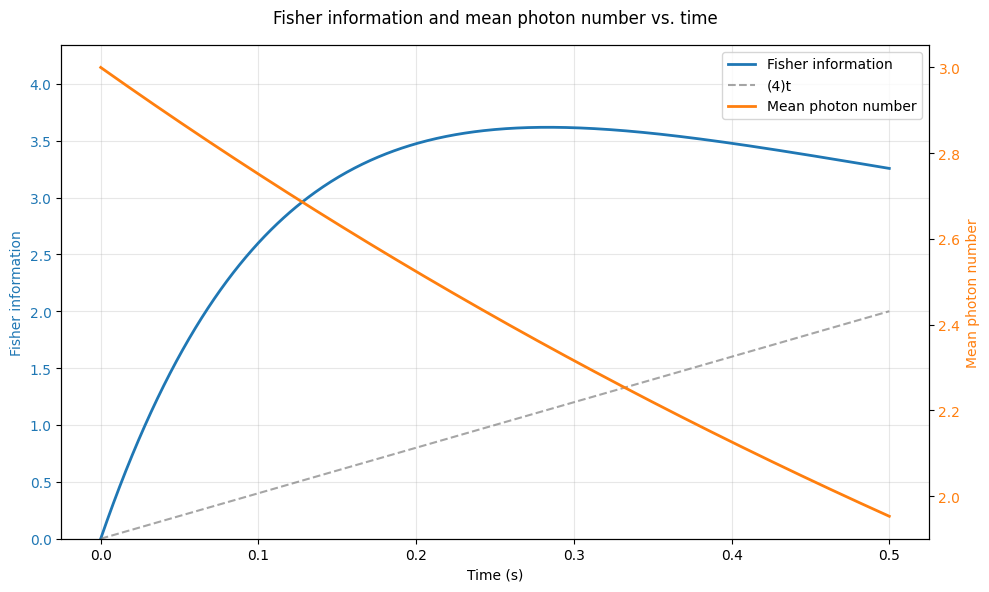

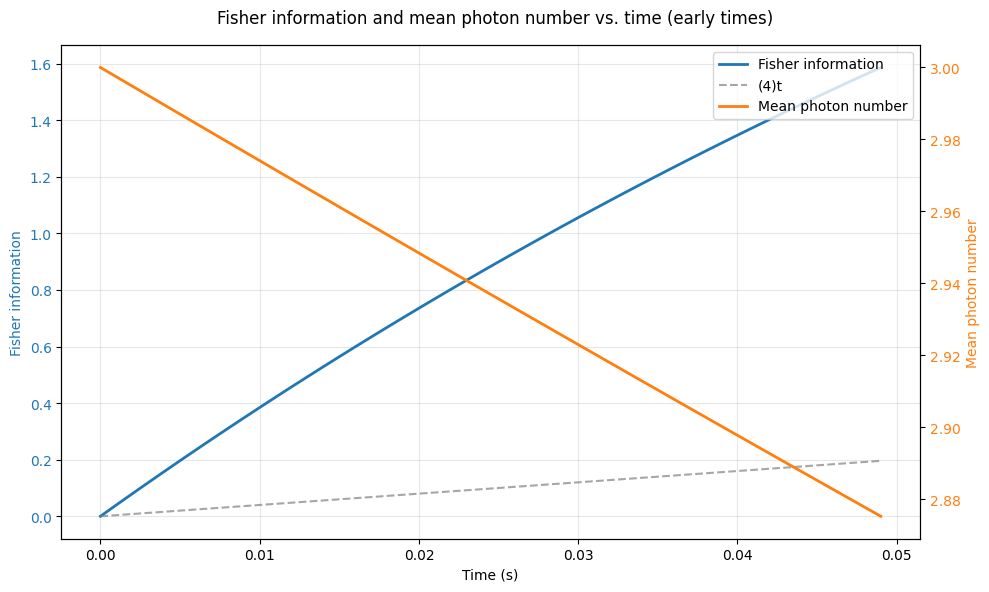

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Fisher information
ax1.plot(times, fisher_infos, color='tab:blue', label='Fisher information', linewidth=2)
ax1.plot(times, (n+1) * times, label=f'({n+1})t', linestyle='--', color='gray', alpha=0.7)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Fisher information', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(0, 1.2 * max(fisher_infos))
ax1.grid(True, alpha=0.3)

# Plot mean photon number on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(times, mean_photons_center, color='tab:orange', label='Mean photon number', linewidth=2)
ax2.set_ylabel('Mean photon number', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.suptitle('Fisher information and mean photon number vs. time')
fig.tight_layout()
plt.show()

# Also create a zoomed-in plot for early times
fig, ax1 = plt.subplots(figsize=(10, 6))

# Find indices for early times (e.g., first 50 steps)
early_idx = min(50, len(times))
times_early = times[:early_idx]
fisher_early = fisher_infos[:early_idx]
mean_photons_early = mean_photons_center[:early_idx]

ax1.plot(times_early, fisher_early, color='tab:blue', label='Fisher information', linewidth=2)
ax1.plot(times_early, (n+1) * times_early, label=f'({n+1})t', linestyle='--', color='gray', alpha=0.7)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Fisher information', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(times_early, mean_photons_early, color='tab:orange', label='Mean photon number', linewidth=2)
ax2.set_ylabel('Mean photon number', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.suptitle('Fisher information and mean photon number vs. time (early times)')
fig.tight_layout()
plt.show()

Evolution (x3)

In [4]:
# Use the already computed evolution results
# The evolution has already been computed above, so we can use those results directly

# Store results in the expected format for compatibility with existing code
photon_dists = {
    'center': P_center,
    'plus': P_plus, 
    'minus': P_minus
}

mean_photons = {
    'center': mean_photons_center,
    'plus': np.zeros_like(mean_photons_center),  # Not computed above, but not needed
    'minus': np.zeros_like(mean_photons_center)   # Not computed above, but not needed
}

# The CFI in time is already computed as fisher_infos
cfi_in_time = fisher_infos.copy()

print("Evolution results organized for compatibility with existing analysis code.")
print(f"Time points: {len(times)}")
print(f"CFI shape: {cfi_in_time.shape}")
print(f"Probability shapes: center={photon_dists['center'].shape}, plus={photon_dists['plus'].shape}, minus={photon_dists['minus'].shape}")

Evolution results organized for compatibility with existing analysis code.
Time points: 501
CFI shape: (501,)
Probability shapes: center=(501,), plus=(501,), minus=(501,)


Optimise over t

Time of maximum CFI: 0.2840 s
Time step of maximum CFI: 284
Maximum CFI: 3.617390225248647


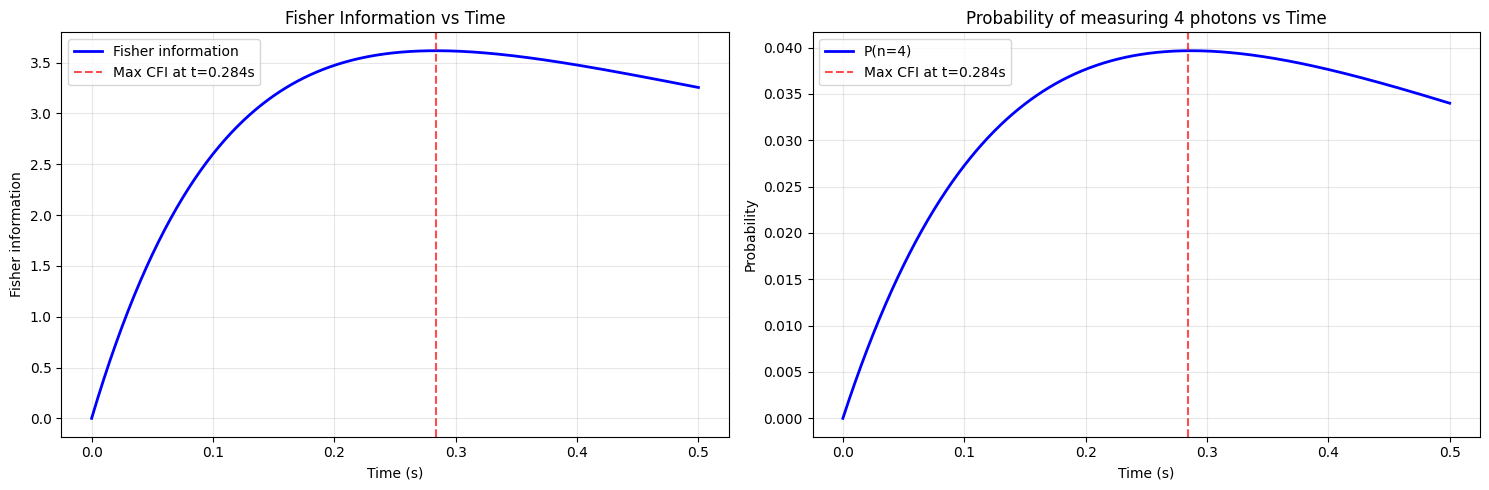

In [5]:
max_cfi_idx = np.argmax(fisher_infos)
max_cfi_time = times[max_cfi_idx]
max_cfi_time_steps = max_cfi_idx
max_cfi = fisher_infos[max_cfi_idx]

print(f"Time of maximum CFI: {max_cfi_time:.4f} s")
print(f"Time step of maximum CFI: {max_cfi_time_steps}")
print(f"Maximum CFI: {max_cfi}")

# Create a summary plot of the optimization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot CFI vs time
ax1.plot(times, fisher_infos, 'b-', linewidth=2, label='Fisher information')
ax1.axvline(x=max_cfi_time, color='red', linestyle='--', alpha=0.7, label=f'Max CFI at t={max_cfi_time:.3f}s')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Fisher information')
ax1.set_title('Fisher Information vs Time')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot probability evolution
ax2.plot(times, P_center, 'b-', linewidth=2, label=f'P(n={n+1})')
ax2.axvline(x=max_cfi_time, color='red', linestyle='--', alpha=0.7, label=f'Max CFI at t={max_cfi_time:.3f}s')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Probability')
ax2.set_title(f'Probability of measuring {n+1} photons vs Time')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Dead time

Dead time: 12 steps = 0.012 s
Total time: 1000 steps = 1.000 s
Optimal interrogation time: 44 steps = 0.0440 s
Number of measurements: 18
Maximum sum CFI: 26.205


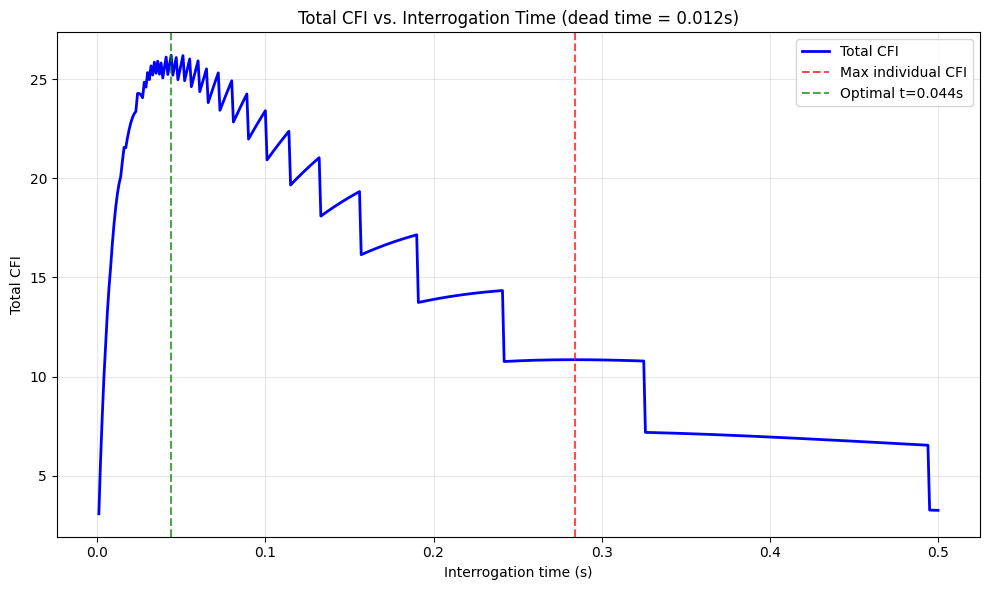

In [6]:
dead_time_steps = 12  # dead time in steps
dead_time_seconds = dead_time_steps * dt  # dead time in seconds
total_time_seconds = 1.0  # total measurement time in seconds
total_steps = int(total_time_seconds / dt)  # total steps

print(f"Dead time: {dead_time_steps} steps = {dead_time_seconds:.3f} s")
print(f"Total time: {total_steps} steps = {total_time_seconds:.3f} s")

# Try all possible interrogation times (must be at least 1 step)
possible_t_steps = np.arange(1, min(total_steps - dead_time_steps + 1, len(times)))
best_sum_cfi = 0
best_t_steps = None

sum_cfi_list = []
for t_meas_steps in possible_t_steps:
    # Number of measurements possible with this interrogation time and dead time
    n_meas = (total_steps + dead_time_steps) // (t_meas_steps + dead_time_steps)
    
    # Get CFI at this interrogation time
    if t_meas_steps < len(fisher_infos):
        cfi = fisher_infos[t_meas_steps]
    else:
        cfi = 0.0
    
    sum_cfi = n_meas * cfi
    sum_cfi_list.append(sum_cfi)
    
    if sum_cfi > best_sum_cfi:
        best_sum_cfi = sum_cfi
        best_t_steps = t_meas_steps

best_t_seconds = best_t_steps * dt
n_measurements = (total_steps + dead_time_steps) // (best_t_steps + dead_time_steps)

print(f"Optimal interrogation time: {best_t_steps} steps = {best_t_seconds:.4f} s")
print(f"Number of measurements: {n_measurements}")
print(f"Maximum sum CFI: {best_sum_cfi:.3f}")

# Convert to time arrays for plotting
possible_t_seconds = possible_t_steps * dt

plt.figure(figsize=(10, 6))
plt.plot(possible_t_seconds, sum_cfi_list, 'b-', linewidth=2, label='Total CFI')
plt.axvline(x=times[np.argmax(fisher_infos)], color='red', linestyle='--', alpha=0.7, label='Max individual CFI')
plt.axvline(x=best_t_seconds, color='green', linestyle='--', alpha=0.7, label=f'Optimal t={best_t_seconds:.3f}s')
plt.xlabel('Interrogation time (s)')
plt.ylabel('Total CFI')
plt.title(f'Total CFI vs. Interrogation Time (dead time = {dead_time_seconds:.3f}s)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Optimal interrogation time (2x dead time): 69 steps = 0.0690 s
Number of measurements: 11
Maximum sum CFI: 22.531


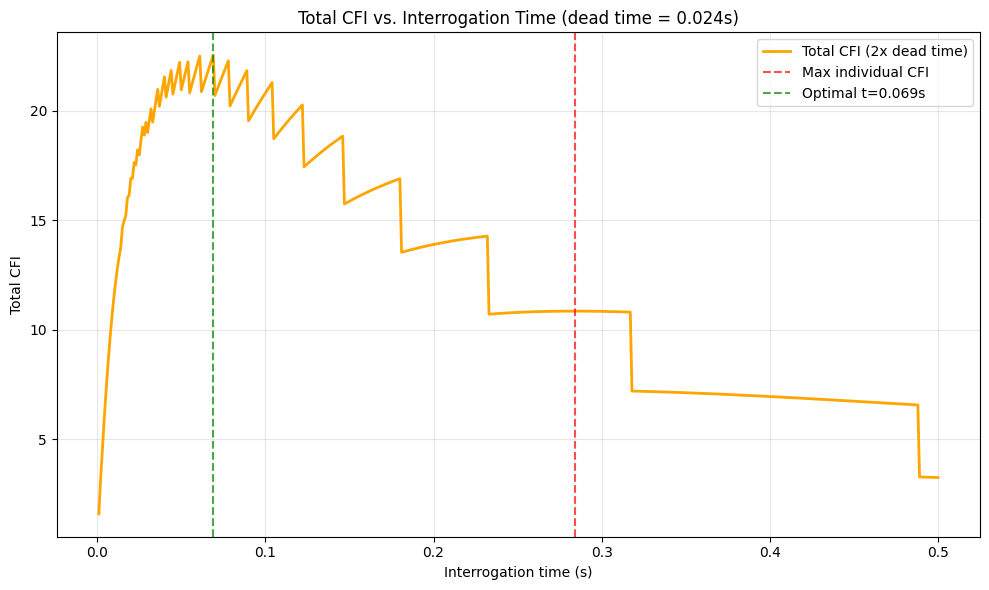

In [7]:
dead_time_steps2 = 2 * dead_time_steps
dead_time_seconds2 = dead_time_steps2 * dt

possible_t_steps2 = np.arange(1, min(total_steps - dead_time_steps2 + 1, len(times)))
sum_cfi_list2 = []
best_sum_cfi2 = 0
best_t_steps2 = None

for t_meas_steps2 in possible_t_steps2:
    n_meas2 = (total_steps + dead_time_steps2) // (t_meas_steps2 + dead_time_steps2)
    
    if t_meas_steps2 < len(fisher_infos):
        cfi2 = fisher_infos[t_meas_steps2]
    else:
        cfi2 = 0.0
    
    sum_cfi2 = n_meas2 * cfi2
    sum_cfi_list2.append(sum_cfi2)
    
    if sum_cfi2 > best_sum_cfi2:
        best_sum_cfi2 = sum_cfi2
        best_t_steps2 = t_meas_steps2

best_t_seconds2 = best_t_steps2 * dt
n_measurements2 = (total_steps + dead_time_steps2) // (best_t_steps2 + dead_time_steps2)

print(f"Optimal interrogation time (2x dead time): {best_t_steps2} steps = {best_t_seconds2:.4f} s")
print(f"Number of measurements: {n_measurements2}")
print(f"Maximum sum CFI: {best_sum_cfi2:.3f}")

possible_t_seconds2 = possible_t_steps2 * dt

plt.figure(figsize=(10, 6))
plt.plot(possible_t_seconds2, sum_cfi_list2, 'orange', linewidth=2, label='Total CFI (2x dead time)')
plt.axvline(x=times[np.argmax(fisher_infos)], color='red', linestyle='--', alpha=0.7, label='Max individual CFI')
plt.axvline(x=best_t_seconds2, color='green', linestyle='--', alpha=0.7, label=f'Optimal t={best_t_seconds2:.3f}s')
plt.xlabel('Interrogation time (s)')
plt.ylabel('Total CFI')
plt.title(f'Total CFI vs. Interrogation Time (dead time = {dead_time_seconds2:.3f}s)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Optimal interrogation time (4x dead time): 83 steps = 0.0830 s
Number of measurements: 8
Maximum sum CFI: 18.562


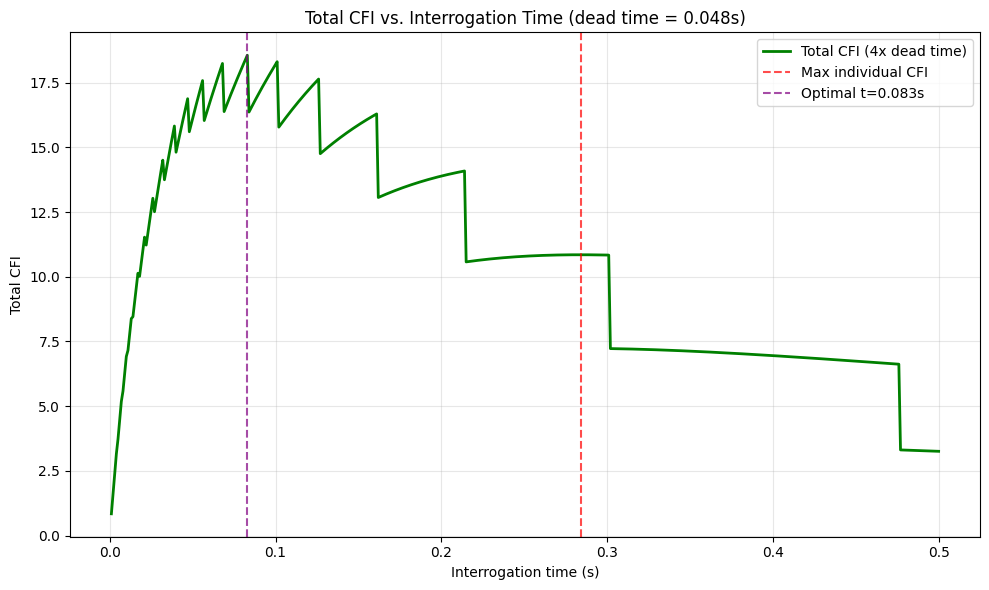

In [8]:
dead_time_steps3 = 4 * dead_time_steps
dead_time_seconds3 = dead_time_steps3 * dt

possible_t_steps3 = np.arange(1, min(total_steps - dead_time_steps3 + 1, len(times)))
sum_cfi_list3 = []
best_sum_cfi3 = 0
best_t_steps3 = None

for t_meas_steps3 in possible_t_steps3:
    n_meas3 = (total_steps + dead_time_steps3) // (t_meas_steps3 + dead_time_steps3)
    
    if t_meas_steps3 < len(fisher_infos):
        cfi3 = fisher_infos[t_meas_steps3]
    else:
        cfi3 = 0.0
    
    sum_cfi3 = n_meas3 * cfi3
    sum_cfi_list3.append(sum_cfi3)
    
    if sum_cfi3 > best_sum_cfi3:
        best_sum_cfi3 = sum_cfi3
        best_t_steps3 = t_meas_steps3

best_t_seconds3 = best_t_steps3 * dt
n_measurements3 = (total_steps + dead_time_steps3) // (best_t_steps3 + dead_time_steps3)

print(f"Optimal interrogation time (4x dead time): {best_t_steps3} steps = {best_t_seconds3:.4f} s")
print(f"Number of measurements: {n_measurements3}")
print(f"Maximum sum CFI: {best_sum_cfi3:.3f}")

possible_t_seconds3 = possible_t_steps3 * dt

plt.figure(figsize=(10, 6))
plt.plot(possible_t_seconds3, sum_cfi_list3, 'green', linewidth=2, label='Total CFI (4x dead time)')
plt.axvline(x=times[np.argmax(fisher_infos)], color='red', linestyle='--', alpha=0.7, label='Max individual CFI')
plt.axvline(x=best_t_seconds3, color='purple', linestyle='--', alpha=0.7, label=f'Optimal t={best_t_seconds3:.3f}s')
plt.xlabel('Interrogation time (s)')
plt.ylabel('Total CFI')
plt.title(f'Total CFI vs. Interrogation Time (dead time = {dead_time_seconds3:.3f}s)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

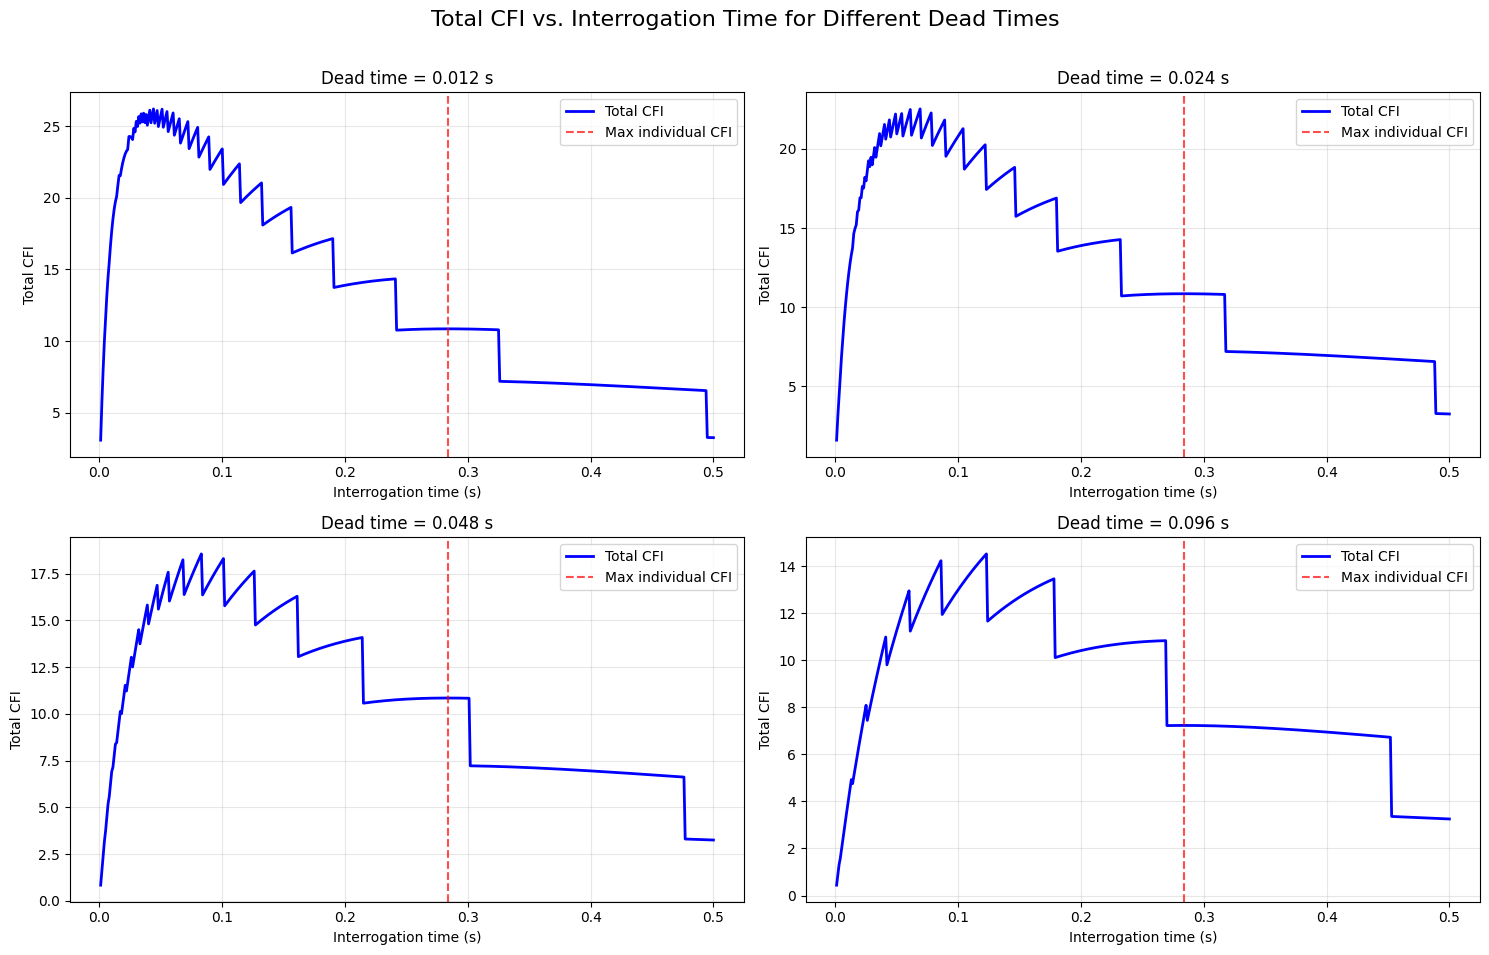

In [9]:
# Compute for 8x dead time
dead_time_steps4 = 8 * dead_time_steps
dead_time_seconds4 = dead_time_steps4 * dt

possible_t_steps4 = np.arange(1, min(total_steps - dead_time_steps4 + 1, len(times)))
sum_cfi_list4 = []
for t_meas_steps4 in possible_t_steps4:
    n_meas4 = (total_steps + dead_time_steps4) // (t_meas_steps4 + dead_time_steps4)
    
    if t_meas_steps4 < len(fisher_infos):
        cfi4 = fisher_infos[t_meas_steps4]
    else:
        cfi4 = 0.0
    
    sum_cfi_list4.append(n_meas4 * cfi4)

possible_t_seconds4 = possible_t_steps4 * dt

# Organize data for plotting
dead_time_seconds_list = [dead_time_seconds, dead_time_seconds2, dead_time_seconds3, dead_time_seconds4]
sum_cfi_lists = [sum_cfi_list, sum_cfi_list2, sum_cfi_list3, sum_cfi_list4]
possible_t_seconds_list = [possible_t_seconds, possible_t_seconds2, possible_t_seconds3, possible_t_seconds4]

titles = [
    f"Dead time = {dead_time_seconds:.3f} s",
    f"Dead time = {dead_time_seconds2:.3f} s", 
    f"Dead time = {dead_time_seconds3:.3f} s",
    f"Dead time = {dead_time_seconds4:.3f} s"
]

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

for i in range(4):
    if len(sum_cfi_lists[i]) > 0:  # Check if we have data
        axs[i].plot(possible_t_seconds_list[i], sum_cfi_lists[i], 'b-', linewidth=2, label='Total CFI')
        axs[i].axvline(x=times[np.argmax(fisher_infos)], color='red', linestyle='--', alpha=0.7, label='Max individual CFI')
        axs[i].set_title(titles[i])
        axs[i].set_xlabel('Interrogation time (s)')
        axs[i].set_ylabel('Total CFI')
        axs[i].grid(True, alpha=0.3)
        axs[i].legend()
    else:
        axs[i].text(0.5, 0.5, 'No data\n(dead time too large)', 
                   transform=axs[i].transAxes, ha='center', va='center')
        axs[i].set_title(titles[i])

fig.suptitle('Total CFI vs. Interrogation Time for Different Dead Times', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

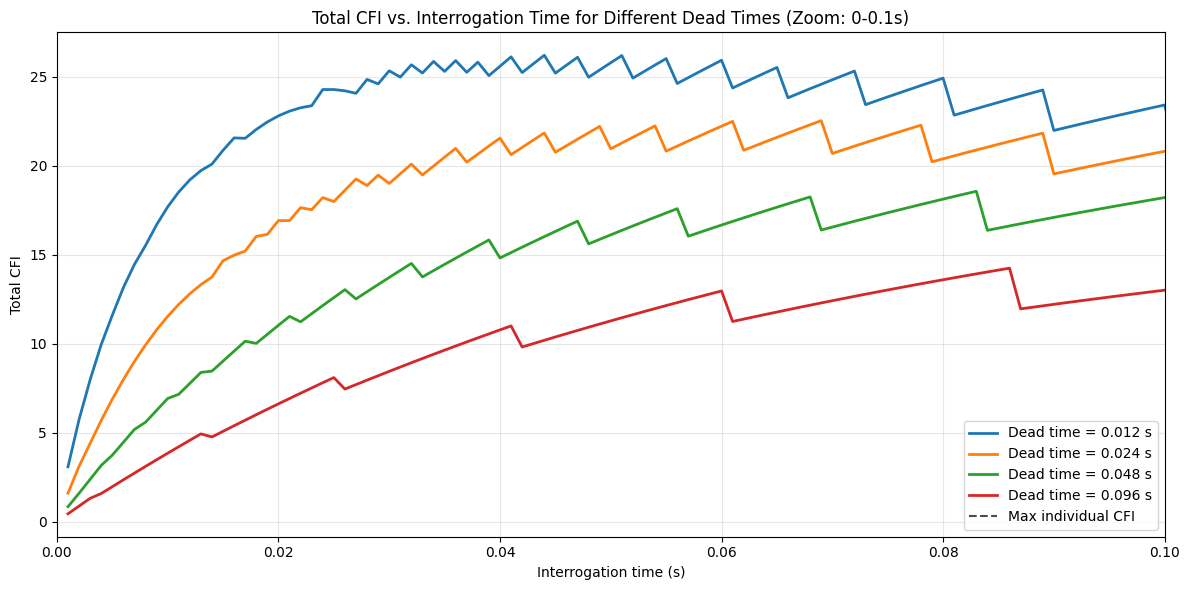

In [10]:
plt.figure(figsize=(12, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for i in range(4):
    if len(sum_cfi_lists[i]) > 0:  # Check if we have data
        plt.plot(possible_t_seconds_list[i], sum_cfi_lists[i], 
                label=titles[i], color=colors[i], linewidth=2)

plt.axvline(x=times[np.argmax(fisher_infos)], color='black', linestyle='--', alpha=0.7, label='Max individual CFI')
plt.xlim(0, 0.1)  # Zoom to first 0.1 seconds
plt.xlabel('Interrogation time (s)')
plt.ylabel('Total CFI')
plt.title('Total CFI vs. Interrogation Time for Different Dead Times (Zoom: 0-0.1s)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

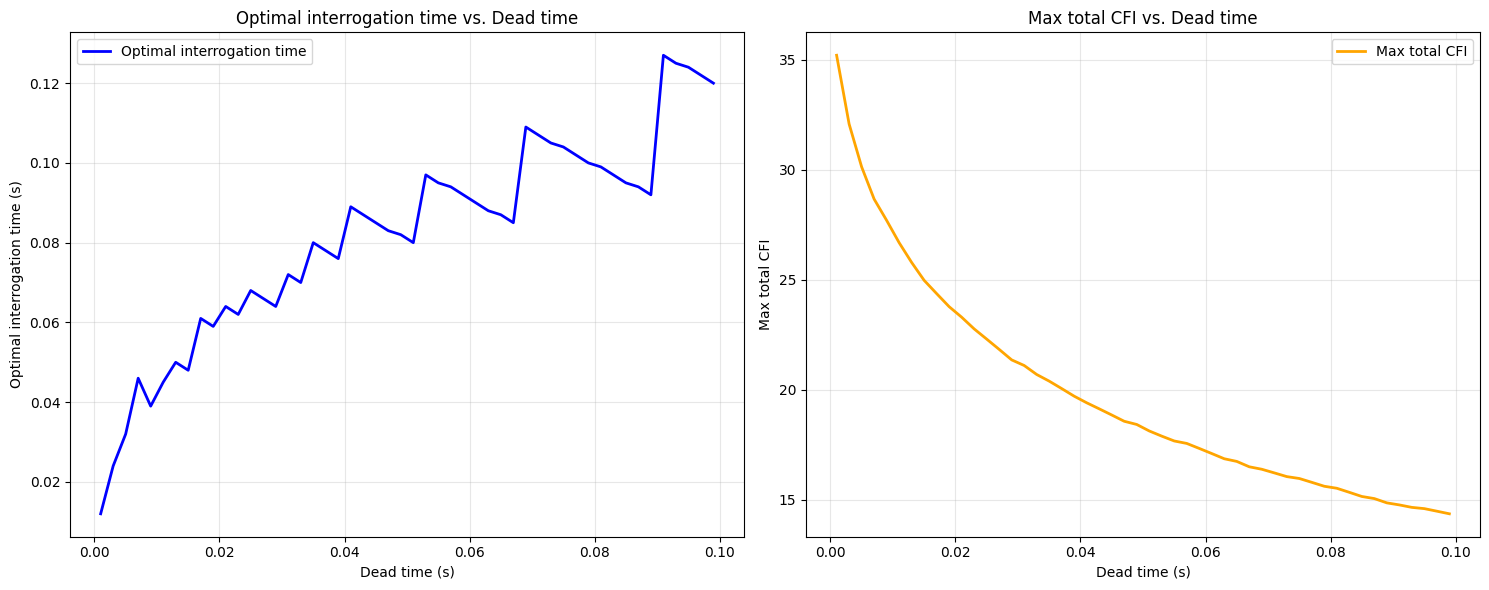

Analysis complete. Time units: seconds
Time step dt = 0.0010 s
Total simulation time = 0.500 s


In [11]:
dead_time_steps_range = np.arange(1, 100, 2)  # Scan dead times from 1 to 100 steps
dead_time_seconds_range = dead_time_steps_range * dt  # Convert to seconds

optimal_t_steps_list = []
optimal_t_seconds_list = []
max_sum_cfi_list = []

for dt_steps in dead_time_steps_range:
    dt_seconds = dt_steps * dt
    
    # Compute possible interrogation times
    possible_t_steps = np.arange(1, min(total_steps - dt_steps + 1, len(times)))
    
    if len(possible_t_steps) == 0:
        # Dead time too large
        optimal_t_steps_list.append(0)
        optimal_t_seconds_list.append(0)
        max_sum_cfi_list.append(0)
        continue
    
    # Compute total CFI for each interrogation time
    sum_cfi_curve = []
    for t_steps in possible_t_steps:
        n_meas = (total_steps + dt_steps) // (t_steps + dt_steps)
        
        if t_steps < len(fisher_infos):
            cfi = fisher_infos[t_steps]
        else:
            cfi = 0.0
        
        sum_cfi_curve.append(n_meas * cfi)
    
    # Find optimal interrogation time
    if len(sum_cfi_curve) > 0:
        max_idx = np.argmax(sum_cfi_curve)
        optimal_t_steps_list.append(possible_t_steps[max_idx])
        optimal_t_seconds_list.append(possible_t_steps[max_idx] * dt)
        max_sum_cfi_list.append(sum_cfi_curve[max_idx])
    else:
        optimal_t_steps_list.append(0)
        optimal_t_seconds_list.append(0)
        max_sum_cfi_list.append(0)

# Convert to arrays
optimal_t_steps_list = np.array(optimal_t_steps_list)
optimal_t_seconds_list = np.array(optimal_t_seconds_list)
max_sum_cfi_list = np.array(max_sum_cfi_list)

# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot optimal interrogation time vs dead time
ax1.plot(dead_time_seconds_range, optimal_t_seconds_list, 'b-', linewidth=2, label='Optimal interrogation time')
ax1.set_xlabel('Dead time (s)')
ax1.set_ylabel('Optimal interrogation time (s)')
ax1.set_title('Optimal interrogation time vs. Dead time')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot max total CFI vs dead time
ax2.plot(dead_time_seconds_range, max_sum_cfi_list, 'orange', linewidth=2, label='Max total CFI')
ax2.set_xlabel('Dead time (s)')
ax2.set_ylabel('Max total CFI')
ax2.set_title('Max total CFI vs. Dead time')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Analysis complete. Time units: seconds")
print(f"Time step dt = {dt:.4f} s")
print(f"Total simulation time = {times[-1]:.3f} s")